In [107]:
import seaborn as sns

In [108]:
import scanpy as sc
import decoupler as dc

# load
adata = sc.read_h5ad("../../data/raw/sciplex/SrivatsanTrapnell2020_sciplex3.h5ad")

# drop any cells missing cell_line
adata = adata[~adata.obs['cell_line'].isna()].copy()

# keep a copy of raw counts
adata.layers['counts'] = adata.X.copy()

# first, make a unique sample ID that encodes exactly the combination you want
bulk_fields = ['well', 'plate', 'cell_line', 'replicate', 'dose_value', 'perturbation', 'time']
for f in bulk_fields:
    if f not in adata.obs:
        raise KeyError(f"adata.obs lacks '{f}'")

# Create sample_id by joining fields with single underscores, ensuring no double underscores
# if dose_value and time are floats that should be integers:
adata.obs['dose_value'] = adata.obs['dose_value'].astype(int)
adata.obs['time']       = adata.obs['time'].astype(int)

# then build sample_id
adata.obs['sample_id'] = adata.obs[bulk_fields] \
    .astype(str) \
    .apply(lambda row: '_'.join(row.values), axis=1)

# decoupler needs a "group" column, but since you want one bulk per sample,
# we just give it a constant group so that each sample_id collapses into exactly one profile
adata.obs['pseudo_group'] = 'all'

In [109]:
# run the pseudobulk
padata = dc.pp.pseudobulk(
    adata,
    sample_col='sample_id',
    groups_col='pseudo_group',
    layer='counts',
)

KeyboardInterrupt: 

In [69]:
# then build sample_id
padata.obs['sample_id'] = padata.obs[bulk_fields] \
    .astype(str) \
    .apply(lambda row: '_'.join(row.values), axis=1)

In [70]:
padata.obs.set_index('sample_id', inplace=True)

In [71]:
padata.obs.drop(columns=['pseudo_group'], inplace=True)

<Axes: xlabel='psbulk_cells', ylabel='Count'>

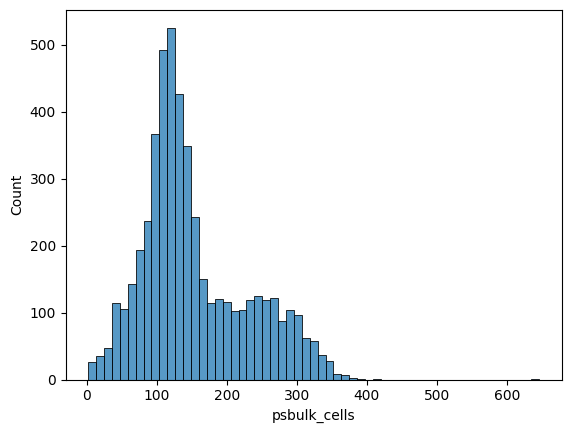

In [ ]:
sns.histplot(padata.obs.psbulk_cells)

In [73]:
padata = padata[padata.obs.psbulk_cells >= 50]

In [74]:
padata.obs.drop(columns=['cancer', 'organism', 'tissue_type', 'perturbation_type'], inplace=True)

In [75]:
import logging
from typing import Dict, Optional

import pandas as pd
import pubchempy as pcp
from tqdm import tqdm
from anndata import AnnData

logger = logging.getLogger(__name__)

def get_pubchem_cid(drug_name: str, cache: Dict[str, Optional[int]]) -> Optional[int]:
    """
    Fetch PubChem CID for a given drug name, using cache to skip repeat lookups.
    """
    if pd.isna(drug_name) or not drug_name:
        return None

    # return cached value if we’ve already looked this one up
    if drug_name in cache:
        return cache[drug_name]

    # otherwise hit PubChem
    try:
        compounds = pcp.get_compounds(drug_name, 'name')
        cid = compounds[0].cid if compounds else None
        logger.debug(f"CID for '{drug_name}': {cid}")
    except Exception as e:
        logger.warning(f"PubChem lookup failed for '{drug_name}': {e}")
        cid = None

    # store result (even None, to avoid hammering the API next time)
    cache[drug_name] = cid
    return cid

def add_pubchem_cids_to_adata(adata: AnnData, cache: Dict[str, Optional[int]]) -> None:
    """
    Add a `pubchem_cid` column to adata.obs based on the 'perturbation' field.
    """
    # grab all unique, non-null perturbations
    unique_drugs = adata.obs['perturbation'].dropna().unique().tolist()

    # find which ones we still need to fetch
    to_fetch = [d for d in unique_drugs if d not in cache]
    if to_fetch:
        logger.info(f"Looking up {len(to_fetch)} new perturbations on PubChem...")
        for drug in tqdm(to_fetch, desc="PubChem CIDs"):
            get_pubchem_cid(drug, cache)

    # map every perturbation to its cached CID (will be None if lookup failed)
    adata.obs['pubchem_cid'] = adata.obs['perturbation'].map(cache)
    return adata

In [76]:
padata = add_pubchem_cids_to_adata(padata, {})

2025-05-30 16:36:09 | [INFO] Looking up 189 new perturbations on PubChem...
PubChem CIDs: 100%|██████████| 189/189 [01:24<00:00,  2.24it/s]


In [91]:
del padata.layers["psbulk_props"]

In [92]:
padata.write_h5ad("../../data/processed/sciplex/pseudbulked_sciplex3.h5ad", compression="gzip")